# MobileNetV3-Large - MIQR-CC usando `train_manifest.csv`, `val_manifest.csv` e `test_manifest.csv`

Notebook individual para treinar e avaliar **MobileNetV3-Large** nas 4 classes do projeto CPRE/MIQR-CC, usando diretamente os splits já existentes


In [2]:
# =========================
# 1. Imports e configuração
# =========================

import os
import gc
import json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large

try:
    from torchvision.models import MobileNet_V3_Large_Weights
except Exception:
    MobileNet_V3_Large_Weights = None

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('PyTorch:', torch.__version__)
print('CUDA disponível:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA PyTorch:', torch.version.cuda)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


PyTorch: 2.6.0+cu124
CUDA disponível: False
Device: cpu


In [3]:
# =========================
# 2. Caminhos e hiperparâmetros
# =========================

DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
SPLITS_DIR = DATA_ROOT / 'MIQR-CC-Dataset-splits'
PROCESSED_DIR = DATASET_DIR / 'processed'

TRAIN_MANIFEST = SPLITS_DIR / 'train_manifest.csv'
VAL_MANIFEST   = SPLITS_DIR / 'val_manifest.csv'
TEST_MANIFEST  = SPLITS_DIR / 'test_manifest.csv'

NOTEBOOK_NAME = 'mobilenetv3_large_manifest_splits_no_focal'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
FIGURES_DIR = RESULTS_DIR / 'figures'
CSV_DIR = RESULTS_DIR / 'csv'

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR, CSV_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Configuração pensada para GPU. Se estiver em CPU, reduz EPOCHS_HEAD/EPOCHS_FT para testes rápidos.
IMG_SIZE = 224
BATCH_SIZE = 32 if torch.cuda.is_available() else 8
NUM_WORKERS = 4

EPOCHS_HEAD = 8
EPOCHS_FT = 12
PATIENCE = 5

LR_HEAD = 1e-3
LR_FT = 1e-4
WEIGHT_DECAY = 1e-4

USE_WEIGHTED_SAMPLER = True
USE_CLASS_WEIGHTS = True
USE_CLAHE = False
USE_PAD_RESIZE = True

MODEL_PATH = MODELS_DIR / 'best_mobilenetv3_large_manifest_no_focal.pth'
BASELINE_MACRO_F1 = 0.738

print('DATASET_DIR:', DATASET_DIR)
print('SPLITS_DIR:', SPLITS_DIR)
print('TRAIN_MANIFEST existe:', TRAIN_MANIFEST.exists())
print('VAL_MANIFEST existe:', VAL_MANIFEST.exists())
print('TEST_MANIFEST existe:', TEST_MANIFEST.exists())
print('MODEL_PATH:', MODEL_PATH)


DATASET_DIR: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset
SPLITS_DIR: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits
TRAIN_MANIFEST existe: True
VAL_MANIFEST existe: True
TEST_MANIFEST existe: True
MODEL_PATH: /mounts/mecd-ap-g5/models/mobilenetv3_large_manifest_splits_no_focal/best_mobilenetv3_large_manifest_no_focal.pth


## 3. Leitura dos manifests

Esta célula lê diretamente os três CSVs. O notebook tenta ser robusto a diferentes nomes de colunas: `final_label`, `label`, `Label`, `processed_image_path`, `image_path`, `path`, etc.


In [4]:
# =========================
# 3. Carregar manifests
# =========================

for p in [TRAIN_MANIFEST, VAL_MANIFEST, TEST_MANIFEST]:
    assert p.exists(), f'Ficheiro não encontrado: {p}'

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df = pd.read_csv(VAL_MANIFEST)
test_df = pd.read_csv(TEST_MANIFEST)

print('Train:', train_df.shape)
print('Val:', val_df.shape)
print('Test:', test_df.shape)
print('\nColunas train:', train_df.columns.tolist())
display(train_df.head())


Train: (1067, 6)
Val: (234, 6)
Test: (267, 6)

Colunas train: ['patient_id', 'Label', 'final_label', 'image_type', 'image_path', 'split']


,patient_id,Label,final_label,image_type,image_path,split
0,5,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
1,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
2,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
3,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
4,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train


In [5]:
# =========================
# 4. Normalizar labels e resolver caminhos
# =========================

FINAL_CLASSES = ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
class_names = FINAL_CLASSES
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}


def normalize_label(label):
    if pd.isna(label):
        return None
    original = str(label).strip()
    key = original.lower().replace('_', ' ').replace('-', ' ')
    key = ' '.join(key.split())

    if key in {'', 'nan', 'unlabeled', 'unlabelled', 'unlabbeled'}:
        return None
    if key in {'biliary leaks', 'biliary leak', 'bile leaks', 'bile leak'}:
        return 'Biliary_Leaks'
    if key in {'lithiasis', 'biliary lithiasis', 'stones', 'stone'}:
        return 'Lithiasis'
    if key in {'normal', 'normals'}:
        return 'Normal'
    if 'stricture' in key:
        return 'Stricture'
    return None


def find_label_column(df):
    for col in ['final_label', 'label', 'Label', 'class', 'Class', 'diagnosis', 'target_name']:
        if col in df.columns:
            return col
    return None


def find_path_column(df):
    candidates = [
        'image_path', 'processed_image_path', 'path', 'filepath', 'file_path',
        'filename', 'file', 'image', 'img_path'
    ]
    for col in candidates:
        if col in df.columns:
            return col
    # fallback: procurar colunas que tenham path no nome
    for col in df.columns:
        if 'path' in col.lower() or 'file' in col.lower() or 'image' in col.lower():
            return col
    return None


def resolve_image_path(value, split_name=None):
    s = str(value)
    p = Path(s)

    candidates = []

    # 1) caminho absoluto ou relativo já válido
    candidates.append(p)

    # 2) relativo à pasta do dataset original
    candidates.append(DATASET_DIR / s)

    # 3) relativo à pasta processed original
    candidates.append(PROCESSED_DIR / s)
    candidates.append(PROCESSED_DIR / p.name)

    # 4) relativo à pasta dos splits
    candidates.append(SPLITS_DIR / s)
    if split_name is not None:
        candidates.append(SPLITS_DIR / split_name / s)
        candidates.append(SPLITS_DIR / split_name / p.name)

    # 5) caso o manifest tenha 'processed/x.png'
    if 'processed' in p.parts:
        candidates.append(DATASET_DIR / s)

    for c in candidates:
        try:
            if c.exists():
                return str(c)
        except OSError:
            pass

    # devolve a hipótese mais provável para facilitar debug
    if split_name is not None:
        return str(SPLITS_DIR / split_name / p.name)
    return str(DATASET_DIR / s)


def prepare_manifest(df, split_name):
    df = df.copy()

    label_col = find_label_column(df)
    if label_col is None:
        raise ValueError(f'Não encontrei coluna de label no split {split_name}. Colunas: {df.columns.tolist()}')

    if label_col == 'final_label':
        df['final_label'] = df['final_label'].apply(normalize_label)
    else:
        df['final_label'] = df[label_col].apply(normalize_label)

    df = df[df['final_label'].isin(FINAL_CLASSES)].copy()

    path_col = find_path_column(df)
    if path_col is None:
        raise ValueError(f'Não encontrei coluna de caminho de imagem no split {split_name}. Colunas: {df.columns.tolist()}')

    df['image_path'] = df[path_col].apply(lambda x: resolve_image_path(x, split_name=split_name))
    df['file_exists'] = df['image_path'].apply(lambda x: Path(x).exists())

    missing = int((~df['file_exists']).sum())
    if missing > 0:
        print(f'Atenção: {missing} imagens em {split_name} não foram encontradas e serão removidas.')
        display(df.loc[~df['file_exists'], [path_col, 'image_path']].head())

    df = df[df['file_exists']].drop(columns=['file_exists']).reset_index(drop=True)
    df['target'] = df['final_label'].map(class_to_idx).astype(int)
    df['split'] = split_name

    return df

train_df = prepare_manifest(train_df, 'train')
val_df = prepare_manifest(val_df, 'val')
test_df = prepare_manifest(test_df, 'test')

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print('\n', name.upper())
    print('N imagens:', len(split_df))
    if 'patient_id' in split_df.columns:
        print('N pacientes:', split_df['patient_id'].nunique())
    print(split_df['final_label'].value_counts().reindex(class_names, fill_value=0))

# Verificação de leakage, se existir patient_id nos manifests
if all('patient_id' in df.columns for df in [train_df, val_df, test_df]):
    train_patients = set(train_df['patient_id'])
    val_patients = set(val_df['patient_id'])
    test_patients = set(test_df['patient_id'])
    print('\nLeakage patient_id:')
    print('train-val:', len(train_patients & val_patients))
    print('train-test:', len(train_patients & test_patients))
    print('val-test:', len(val_patients & test_patients))

train_df.to_csv(CSV_DIR / 'train_manifest_prepared.csv', index=False)
val_df.to_csv(CSV_DIR / 'val_manifest_prepared.csv', index=False)
test_df.to_csv(CSV_DIR / 'test_manifest_prepared.csv', index=False)



 TRAIN
N imagens: 1067
N pacientes: 305
final_label
Biliary_Leaks    110
Lithiasis        505
Normal           197
Stricture        255
Name: count, dtype: int64

 VAL
N imagens: 234
N pacientes: 65
final_label
Biliary_Leaks    24
Lithiasis        98
Normal           59
Stricture        53
Name: count, dtype: int64

 TEST
N imagens: 267
N pacientes: 66
final_label
Biliary_Leaks     17
Lithiasis        123
Normal            43
Stricture         84
Name: count, dtype: int64

Leakage patient_id:
train-val: 0
train-test: 0
val-test: 0


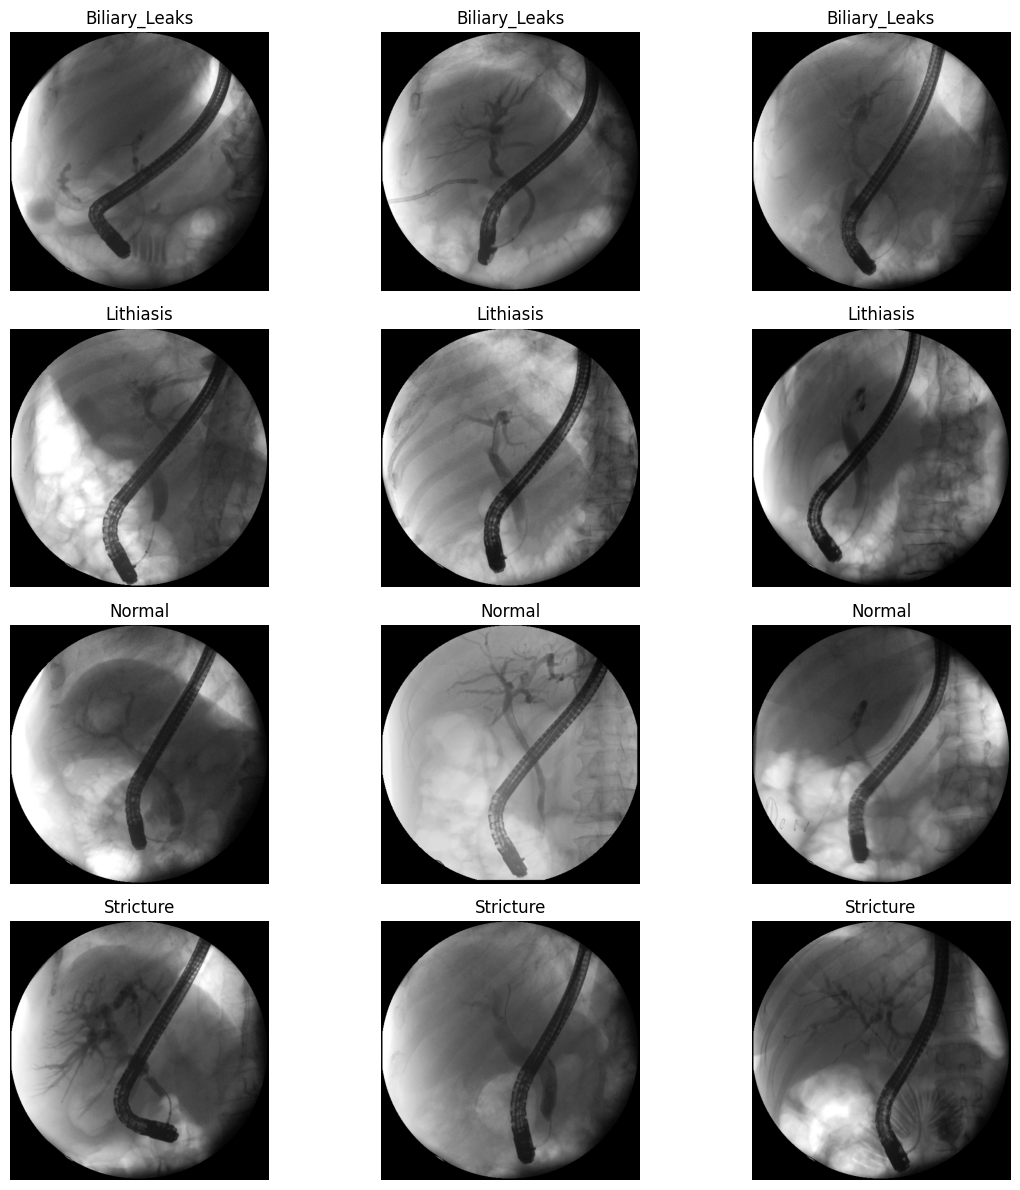

In [6]:
# =========================
# 5. Visualizar exemplos
# =========================

def show_examples_per_class(dataframe, n_per_class=3):
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(4*n_per_class, 3*len(class_names)))
    if len(class_names) == 1:
        axes = np.expand_dims(axes, 0)

    for row_idx, class_name in enumerate(class_names):
        subset = dataframe[dataframe['final_label'] == class_name]
        if len(subset) > 0:
            subset = subset.sample(n=min(n_per_class, len(subset)), random_state=SEED)
        for col_idx in range(n_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis('off')
            if col_idx < len(subset):
                img = Image.open(subset.iloc[col_idx]['image_path']).convert('RGB')
                ax.imshow(img, cmap='gray')
                ax.set_title(class_name)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'examples_per_class.png', dpi=300, bbox_inches='tight')
    plt.show()

show_examples_per_class(train_df, n_per_class=3)


## 4. Dataset, transformações e DataLoaders

In [7]:
# =========================
# 6. Pré-processamento e Dataset
# =========================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def apply_clahe_rgb(pil_img):
    # CLAHE no canal de luminância. Útil para imagens fluoroscópicas.
    import cv2
    img = np.array(pil_img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    rgb = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb)


class PadToSquare:
    def __init__(self, fill=0):
        self.fill = fill

    def __call__(self, img):
        w, h = img.size
        if w == h:
            return img
        size = max(w, h)
        new_img = Image.new('RGB', (size, size), color=(self.fill, self.fill, self.fill))
        left = (size - w) // 2
        top = (size - h) // 2
        new_img.paste(img, (left, top))
        return new_img


class CLAHETransform:
    def __call__(self, img):
        return apply_clahe_rgb(img)


base_resize = []
if USE_CLAHE:
    base_resize.append(CLAHETransform())
if USE_PAD_RESIZE:
    base_resize.append(PadToSquare(fill=0))
base_resize.append(T.Resize((IMG_SIZE, IMG_SIZE)))

train_transform = T.Compose(base_resize + [
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=8),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose(base_resize + [
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MIQRDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = int(row['target'])
        return img, label

train_dataset = MIQRDataset(train_df, transform=train_transform)
val_dataset = MIQRDataset(val_df, transform=eval_transform)
test_dataset = MIQRDataset(test_df, transform=eval_transform)

print('Dataset sizes:', len(train_dataset), len(val_dataset), len(test_dataset))


Dataset sizes: 1067 234 267


In [8]:
# =========================
# 7. Class weights, sampler e DataLoaders
# =========================

train_targets = train_df['target'].values
class_counts = np.bincount(train_targets, minlength=len(class_names))
print('Class counts train:', dict(zip(class_names, class_counts)))

# Pesos inversamente proporcionais à frequência das classes
class_weights_np = len(train_targets) / (len(class_names) * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print('Class weights:', dict(zip(class_names, class_weights_np.round(4))))

if USE_WEIGHTED_SAMPLER:
    sample_weights = class_weights_np[train_targets]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    shuffle_train = False
else:
    sampler = None
    shuffle_train = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=shuffle_train,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


Class counts train: {'Biliary_Leaks': np.int64(110), 'Lithiasis': np.int64(505), 'Normal': np.int64(197), 'Stricture': np.int64(255)}
Class weights: {'Biliary_Leaks': np.float64(2.425), 'Lithiasis': np.float64(0.5282), 'Normal': np.float64(1.3541), 'Stricture': np.float64(1.0461)}


## 5. Modelo MobileNetV3-Large

O treino é feito em duas fases:

1. treino apenas da cabeça de classificação;
2. fine-tuning parcial das últimas camadas.


In [9]:
# =========================
# 8. Construção do modelo
# =========================

def build_mobilenet_v3_large(num_classes):
    if MobileNet_V3_Large_Weights is not None:
        weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
        model = mobilenet_v3_large(weights=weights)
    else:
        model = mobilenet_v3_large(pretrained=True)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_mobilenet_v3_large(num_classes=len(class_names)).to(device)

# Perda sem Focal Loss: CrossEntropyLoss ponderada
if USE_CLASS_WEIGHTS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

print(model.classifier)
print('Loss:', criterion)


Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=4, bias=True)
)
Loss: CrossEntropyLoss()


In [10]:
# =========================
# 9. Métricas e funções auxiliares
# =========================

def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

    if y_prob is not None:
        try:
            y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
            metrics['roc_auc_macro_ovr'] = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
            metrics['pr_auc_macro'] = average_precision_score(y_bin, y_prob, average='macro')
        except Exception as e:
            metrics['roc_auc_macro_ovr'] = np.nan
            metrics['pr_auc_macro'] = np.nan
    return metrics


def evaluate(model, loader):
    model.eval()
    all_y = []
    all_pred = []
    all_prob = []
    total_loss = 0.0
    n_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            bs = labels.size(0)
            total_loss += loss.item() * bs
            n_samples += bs

            all_y.append(labels.cpu().numpy())
            all_pred.append(preds.cpu().numpy())
            all_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics['loss'] = total_loss / max(n_samples, 1)
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_prob'] = y_prob
    return metrics


def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0.0
    n_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        n_samples += bs

    return total_loss / max(n_samples, 1)


def set_trainable_backbone(model, trainable=False, last_n_blocks=0):
    # Congelar tudo
    for p in model.features.parameters():
        p.requires_grad = False

    # Descongelar últimos blocos, se pedido
    if trainable and last_n_blocks > 0:
        for block in model.features[-last_n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

    # Classifier fica sempre treinável
    for p in model.classifier.parameters():
        p.requires_grad = True


def fit_phase(model, phase_name, epochs, lr, train_backbone=False, last_n_blocks=0):
    global best_val_f1, best_state

    set_trainable_backbone(model, trainable=train_backbone, last_n_blocks=last_n_blocks)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)

    history = []
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_metrics = evaluate(model, val_loader)

        row = {
            'phase': phase_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_balanced_accuracy': val_metrics['balanced_accuracy'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_weighted_f1': val_metrics['weighted_f1'],
            'lr': lr,
        }
        history.append(row)

        print(
            f"[{phase_name}] epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_state = copy.deepcopy(model.state_dict())
            torch.save({
                'model_state_dict': best_state,
                'class_names': class_names,
                'class_to_idx': class_to_idx,
                'best_val_macro_f1': best_val_f1,
                'phase': phase_name,
                'epoch': epoch,
                'config': {
                    'IMG_SIZE': IMG_SIZE,
                    'BATCH_SIZE': BATCH_SIZE,
                    'USE_CLASS_WEIGHTS': USE_CLASS_WEIGHTS,
                    'USE_WEIGHTED_SAMPLER': USE_WEIGHTED_SAMPLER,
                    'USE_CLAHE': USE_CLAHE,
                    'USE_PAD_RESIZE': USE_PAD_RESIZE,
                    'loss': 'CrossEntropyLoss_weighted' if USE_CLASS_WEIGHTS else 'CrossEntropyLoss',
                }
            }, MODEL_PATH)
            print(f'  Novo melhor modelo guardado: {MODEL_PATH} | val_macro_f1={best_val_f1:.4f}')
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f'  Early stopping em {phase_name}.')
                break

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return history


In [11]:
# =========================
# 10. Treino
# =========================

best_val_f1 = -1.0
best_state = None

# Fase 1: treinar só a cabeça
hist_head = fit_phase(
    model,
    phase_name='head',
    epochs=EPOCHS_HEAD,
    lr=LR_HEAD,
    train_backbone=False,
    last_n_blocks=0,
)

# Fase 2: fine-tuning parcial dos últimos blocos
hist_ft = fit_phase(
    model,
    phase_name='fine_tuning',
    epochs=EPOCHS_FT,
    lr=LR_FT,
    train_backbone=True,
    last_n_blocks=4,
)

print('Melhor val macro F1:', best_val_f1)

# Carregar melhor checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)


[head] epoch 01/8 | train_loss=1.1695 | val_loss=1.4954 | val_macro_f1=0.2255 | val_bal_acc=0.2577
  Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/mobilenetv3_large_manifest_splits_no_focal/best_mobilenetv3_large_manifest_no_focal.pth | val_macro_f1=0.2255
[head] epoch 02/8 | train_loss=0.9628 | val_loss=1.4612 | val_macro_f1=0.2571 | val_bal_acc=0.3498
  Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/mobilenetv3_large_manifest_splits_no_focal/best_mobilenetv3_large_manifest_no_focal.pth | val_macro_f1=0.2571
[head] epoch 03/8 | train_loss=0.8998 | val_loss=1.9103 | val_macro_f1=0.1755 | val_bal_acc=0.3096
[head] epoch 04/8 | train_loss=0.7602 | val_loss=1.6543 | val_macro_f1=0.2629 | val_bal_acc=0.3404
  Novo melhor modelo guardado: /mounts/mecd-ap-g5/models/mobilenetv3_large_manifest_splits_no_focal/best_mobilenetv3_large_manifest_no_focal.pth | val_macro_f1=0.2629
[head] epoch 05/8 | train_loss=0.7734 | val_loss=2.3196 | val_macro_f1=0.1994 | val_bal_acc=0.3216
[hea

,phase,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,lr,global_epoch
15,fine_tuning,8,0.156909,1.779848,0.457265,0.412850,0.401115,0.451979,0.0001,16
16,fine_tuning,9,0.135210,1.798396,0.474359,0.443683,0.427227,0.466662,0.0001,17
17,fine_tuning,10,0.102042,1.746978,0.534188,0.538868,0.523004,0.531395,0.0001,18
18,fine_tuning,11,0.113198,1.768043,0.474359,0.442394,0.450448,0.472943,0.0001,19
19,fine_tuning,12,0.111556,1.997528,0.529915,0.449866,0.456584,0.513577,0.0001,20


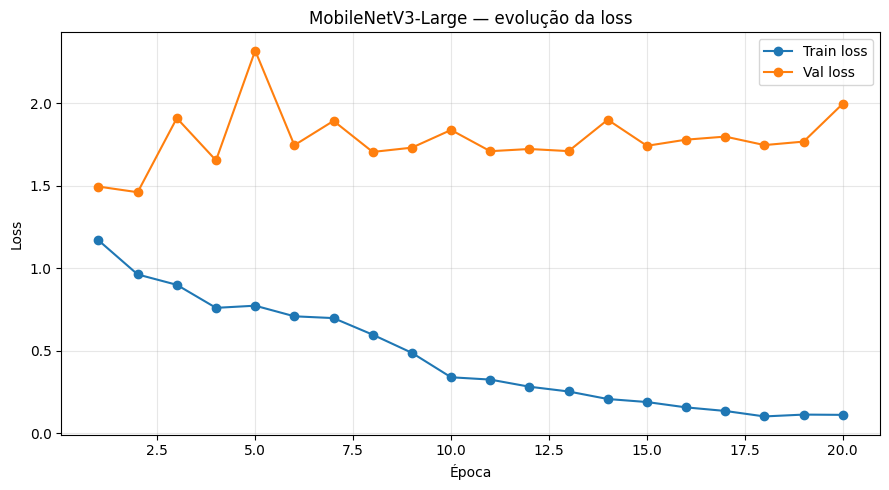

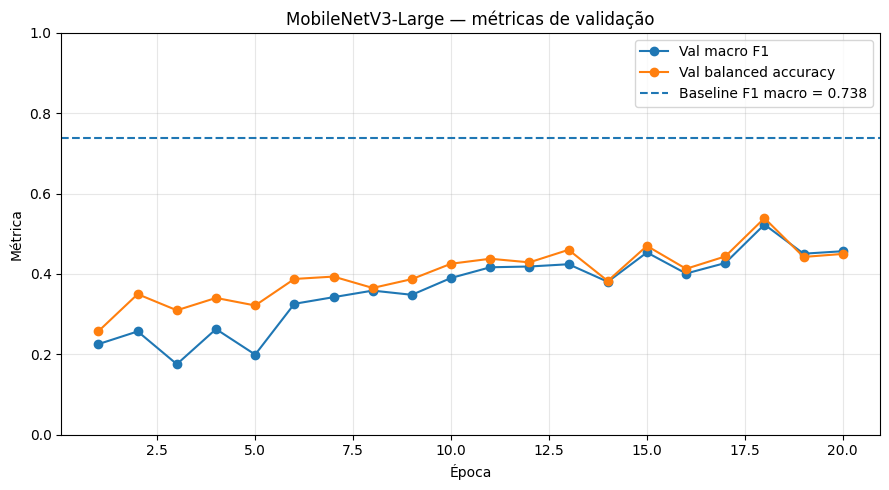

In [12]:
# =========================
# 11. Curvas de treino
# =========================

hist_df = pd.concat([pd.DataFrame(hist_head), pd.DataFrame(hist_ft)], ignore_index=True)
hist_df['global_epoch'] = np.arange(1, len(hist_df) + 1)
hist_df.to_csv(CSV_DIR / 'training_history.csv', index=False)
display(hist_df.tail())

plt.figure(figsize=(9, 5))
plt.plot(hist_df['global_epoch'], hist_df['train_loss'], marker='o', label='Train loss')
plt.plot(hist_df['global_epoch'], hist_df['val_loss'], marker='o', label='Val loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('MobileNetV3-Large — evolução da loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist_df['global_epoch'], hist_df['val_macro_f1'], marker='o', label='Val macro F1')
plt.plot(hist_df['global_epoch'], hist_df['val_balanced_accuracy'], marker='o', label='Val balanced accuracy')
plt.axhline(BASELINE_MACRO_F1, linestyle='--', label=f'Baseline F1 macro = {BASELINE_MACRO_F1}')
plt.xlabel('Época')
plt.ylabel('Métrica')
plt.title('MobileNetV3-Large — métricas de validação')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'validation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Avaliação no teste

In [13]:
# =========================
# 12. Avaliação no teste
# =========================

test_metrics = evaluate(model, test_loader)

print('TEST METRICS')
print('Accuracy:', test_metrics['accuracy'])
print('Balanced accuracy:', test_metrics['balanced_accuracy'])
print('Macro F1:', test_metrics['macro_f1'])
print('Weighted F1:', test_metrics['weighted_f1'])
print('ROC-AUC macro OvR:', test_metrics.get('roc_auc_macro_ovr', np.nan))
print('PR-AUC macro:', test_metrics.get('pr_auc_macro', np.nan))
print('Diferença para baseline F1 macro:', test_metrics['macro_f1'] - BASELINE_MACRO_F1)

print('\nClassification report:')
report_txt = classification_report(
    test_metrics['y_true'],
    test_metrics['y_pred'],
    target_names=class_names,
    zero_division=0,
)
print(report_txt)

report_dict = classification_report(
    test_metrics['y_true'],
    test_metrics['y_pred'],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
pd.DataFrame(report_dict).T.to_csv(CSV_DIR / 'classification_report_test.csv')

summary = {
    'model': 'MobileNetV3-Large',
    'split_mode': 'predefined_manifest_csvs',
    'loss': 'CrossEntropyLoss_weighted' if USE_CLASS_WEIGHTS else 'CrossEntropyLoss',
    'uses_focal_loss': False,
    'uses_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'img_size': IMG_SIZE,
    'best_val_macro_f1': float(best_val_f1),
    'test_accuracy': float(test_metrics['accuracy']),
    'test_balanced_accuracy': float(test_metrics['balanced_accuracy']),
    'test_macro_f1': float(test_metrics['macro_f1']),
    'test_weighted_f1': float(test_metrics['weighted_f1']),
    'test_roc_auc_macro_ovr': float(test_metrics.get('roc_auc_macro_ovr', np.nan)),
    'test_pr_auc_macro': float(test_metrics.get('pr_auc_macro', np.nan)),
    'baseline_macro_f1': BASELINE_MACRO_F1,
    'difference_to_baseline': float(test_metrics['macro_f1'] - BASELINE_MACRO_F1),
    'train_images': int(len(train_df)),
    'val_images': int(len(val_df)),
    'test_images': int(len(test_df)),
}

if all('patient_id' in df.columns for df in [train_df, val_df, test_df]):
    summary.update({
        'train_patients': int(train_df['patient_id'].nunique()),
        'val_patients': int(val_df['patient_id'].nunique()),
        'test_patients': int(test_df['patient_id'].nunique()),
    })

with open(RESULTS_DIR / 'test_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)
pd.DataFrame([summary]).to_csv(CSV_DIR / 'test_summary.csv', index=False)
summary


TEST METRICS
Accuracy: 0.5617977528089888
Balanced accuracy: 0.47177797664726695
Macro F1: 0.46752341455449153
Weighted F1: 0.5653075967662473
ROC-AUC macro OvR: 0.7695046659663279
PR-AUC macro: 0.48460226993039324
Diferença para baseline F1 macro: -0.27047658544550846

Classification report:
               precision    recall  f1-score   support

Biliary_Leaks       0.19      0.24      0.21        17
    Lithiasis       0.64      0.67      0.66       123
       Normal       0.40      0.47      0.43        43
    Stricture       0.65      0.51      0.57        84

     accuracy                           0.56       267
    macro avg       0.47      0.47      0.47       267
 weighted avg       0.58      0.56      0.57       267



{'model': 'MobileNetV3-Large',
 'split_mode': 'predefined_manifest_csvs',
 'loss': 'CrossEntropyLoss_weighted',
 'uses_focal_loss': False,
 'uses_weighted_sampler': True,
 'img_size': 224,
 'best_val_macro_f1': 0.523004463398385,
 'test_accuracy': 0.5617977528089888,
 'test_balanced_accuracy': 0.47177797664726695,
 'test_macro_f1': 0.46752341455449153,
 'test_weighted_f1': 0.5653075967662473,
 'test_roc_auc_macro_ovr': 0.7695046659663279,
 'test_pr_auc_macro': 0.48460226993039324,
 'baseline_macro_f1': 0.738,
 'difference_to_baseline': -0.27047658544550846,
 'train_images': 1067,
 'val_images': 234,
 'test_images': 267,
 'train_patients': 305,
 'val_patients': 65,
 'test_patients': 66}

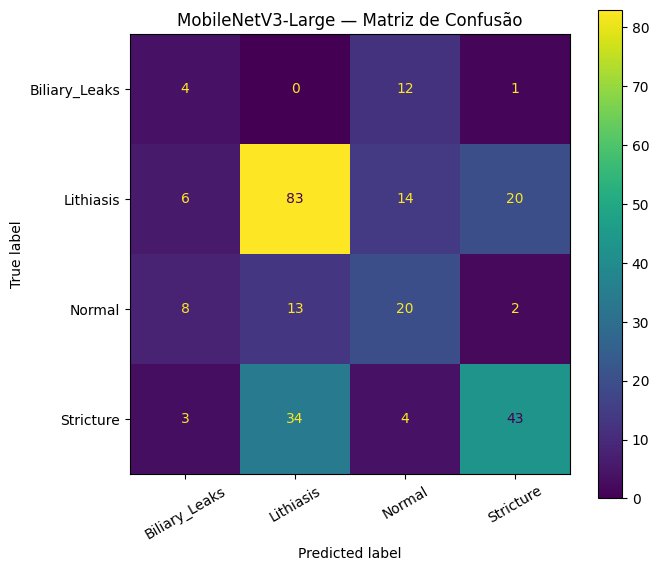

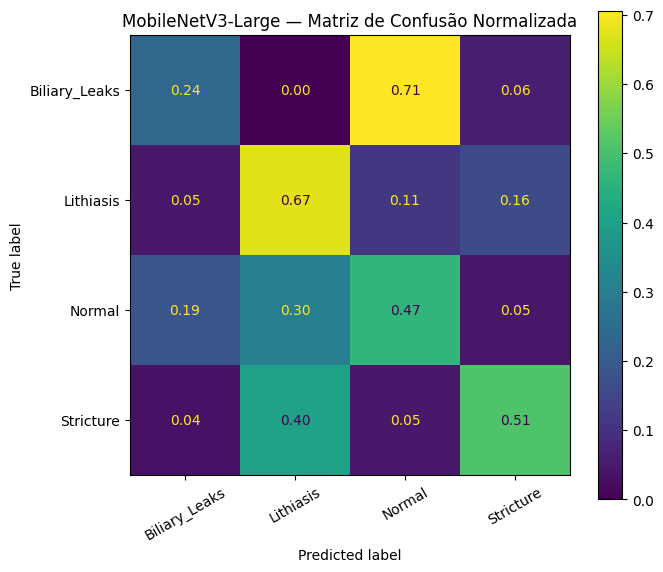

In [14]:
# =========================
# 13. Matriz de confusão
# =========================

cm = confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], labels=list(range(len(class_names))))
cm_norm = confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], labels=list(range(len(class_names))), normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format='d', xticks_rotation=30)
plt.title('MobileNetV3-Large — Matriz de Confusão')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, values_format='.2f', xticks_rotation=30)
plt.title('MobileNetV3-Large — Matriz de Confusão Normalizada')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_test_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(CSV_DIR / 'confusion_matrix_test.csv')
pd.DataFrame(cm_norm, index=class_names, columns=class_names).to_csv(CSV_DIR / 'confusion_matrix_test_normalized.csv')


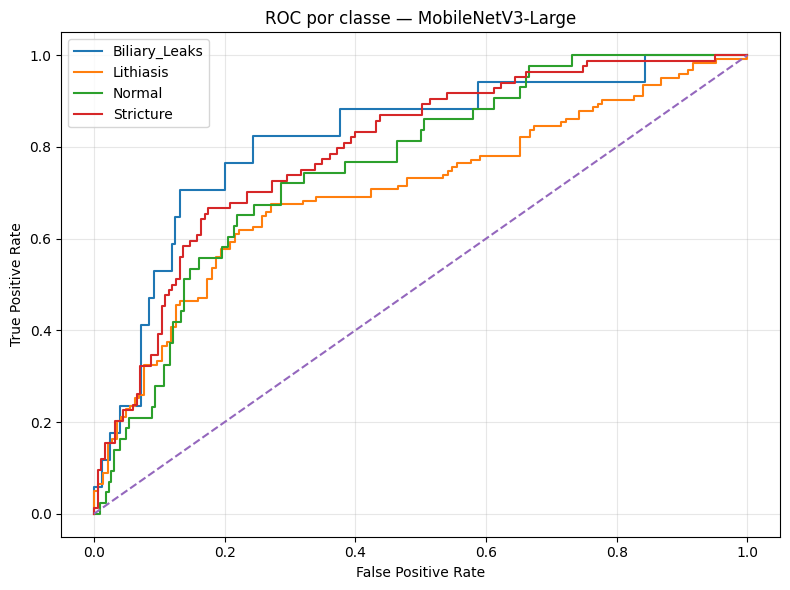

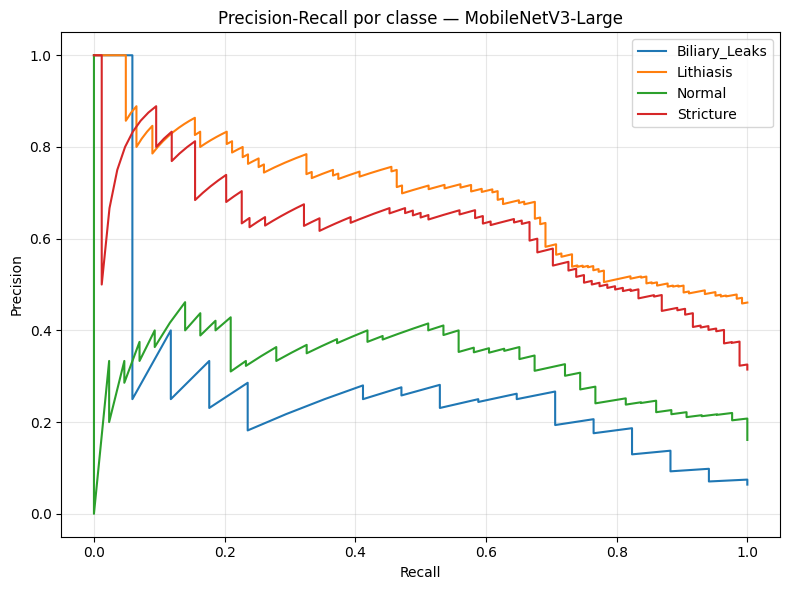

In [15]:
# =========================
# 14. Curvas ROC e Precision-Recall
# =========================

y_true = test_metrics['y_true']
y_prob = test_metrics['y_prob']
y_bin = label_binarize(y_true, classes=list(range(len(class_names))))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    try:
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=class_name)
    except Exception:
        pass
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC por classe — MobileNetV3-Large')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves_test.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    try:
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, label=class_name)
    except Exception:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall por classe — MobileNetV3-Large')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curves_test.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
# =========================
# 15. Guardar probabilidades e análise de erros
# =========================

probs_df = pd.DataFrame(test_metrics['y_prob'], columns=[f'prob_{c}' for c in class_names])
probs_df['true_idx'] = test_metrics['y_true']
probs_df['pred_idx'] = test_metrics['y_pred']
probs_df['true_label'] = [idx_to_class[i] for i in test_metrics['y_true']]
probs_df['pred_label'] = [idx_to_class[i] for i in test_metrics['y_pred']]
probs_df['confidence'] = test_metrics['y_prob'].max(axis=1)
probs_df['correct'] = probs_df['true_idx'] == probs_df['pred_idx']
probs_df['image_path'] = test_df.reset_index(drop=True)['image_path'].values

probs_df.to_csv(CSV_DIR / 'test_probabilities.csv', index=False)
display(probs_df.head())

errors_df = probs_df[~probs_df['correct']].sort_values('confidence', ascending=False)
errors_df.to_csv(CSV_DIR / 'test_errors.csv', index=False)
print('N erros:', len(errors_df))
display(errors_df.head(10))


,prob_Biliary_Leaks,prob_Lithiasis,prob_Normal,prob_Stricture,true_idx,pred_idx,true_label,pred_label,confidence,correct,image_path
0,0.988406,0.001464,0.009883,0.000247,2,0,Normal,Biliary_Leaks,0.988406,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
1,0.995824,0.000290,0.001457,0.002429,1,0,Lithiasis,Biliary_Leaks,0.995824,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
2,0.000033,0.189440,0.319810,0.490717,1,3,Lithiasis,Stricture,0.490717,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
3,0.000051,0.085477,0.333515,0.580957,1,3,Lithiasis,Stricture,0.580957,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
4,0.000043,0.027221,0.024239,0.948496,1,3,Lithiasis,Stricture,0.948496,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...


N erros: 117


,prob_Biliary_Leaks,prob_Lithiasis,prob_Normal,prob_Stricture,true_idx,pred_idx,true_label,pred_label,confidence,correct,image_path
33,2.064541e-06,0.996001,0.002307,0.001690,3,1,Stricture,Lithiasis,0.996001,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
1,9.958245e-01,0.000290,0.001457,0.002429,1,0,Lithiasis,Biliary_Leaks,0.995824,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
228,2.669678e-03,0.002575,0.994626,0.000130,0,2,Biliary_Leaks,Normal,0.994626,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
81,2.154074e-05,0.992768,0.000309,0.006901,3,1,Stricture,Lithiasis,0.992768,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
102,4.160372e-07,0.006146,0.002405,0.991449,1,3,Lithiasis,Stricture,0.991449,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
21,7.625219e-06,0.989917,0.006363,0.003712,3,1,Stricture,Lithiasis,0.989917,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
77,1.005182e-04,0.009932,0.989713,0.000255,1,2,Lithiasis,Normal,0.989713,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
0,9.884064e-01,0.001464,0.009883,0.000247,2,0,Normal,Biliary_Leaks,0.988406,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
205,2.076774e-04,0.979827,0.002684,0.017282,3,1,Stricture,Lithiasis,0.979827,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
223,1.341760e-02,0.006907,0.979602,0.000073,0,2,Biliary_Leaks,Normal,0.979602,False,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...


## 7. Grad-CAM opcional

Esta secção gera exemplos de interpretabilidade. Pode ser desligada se só quiseres treino e métricas.


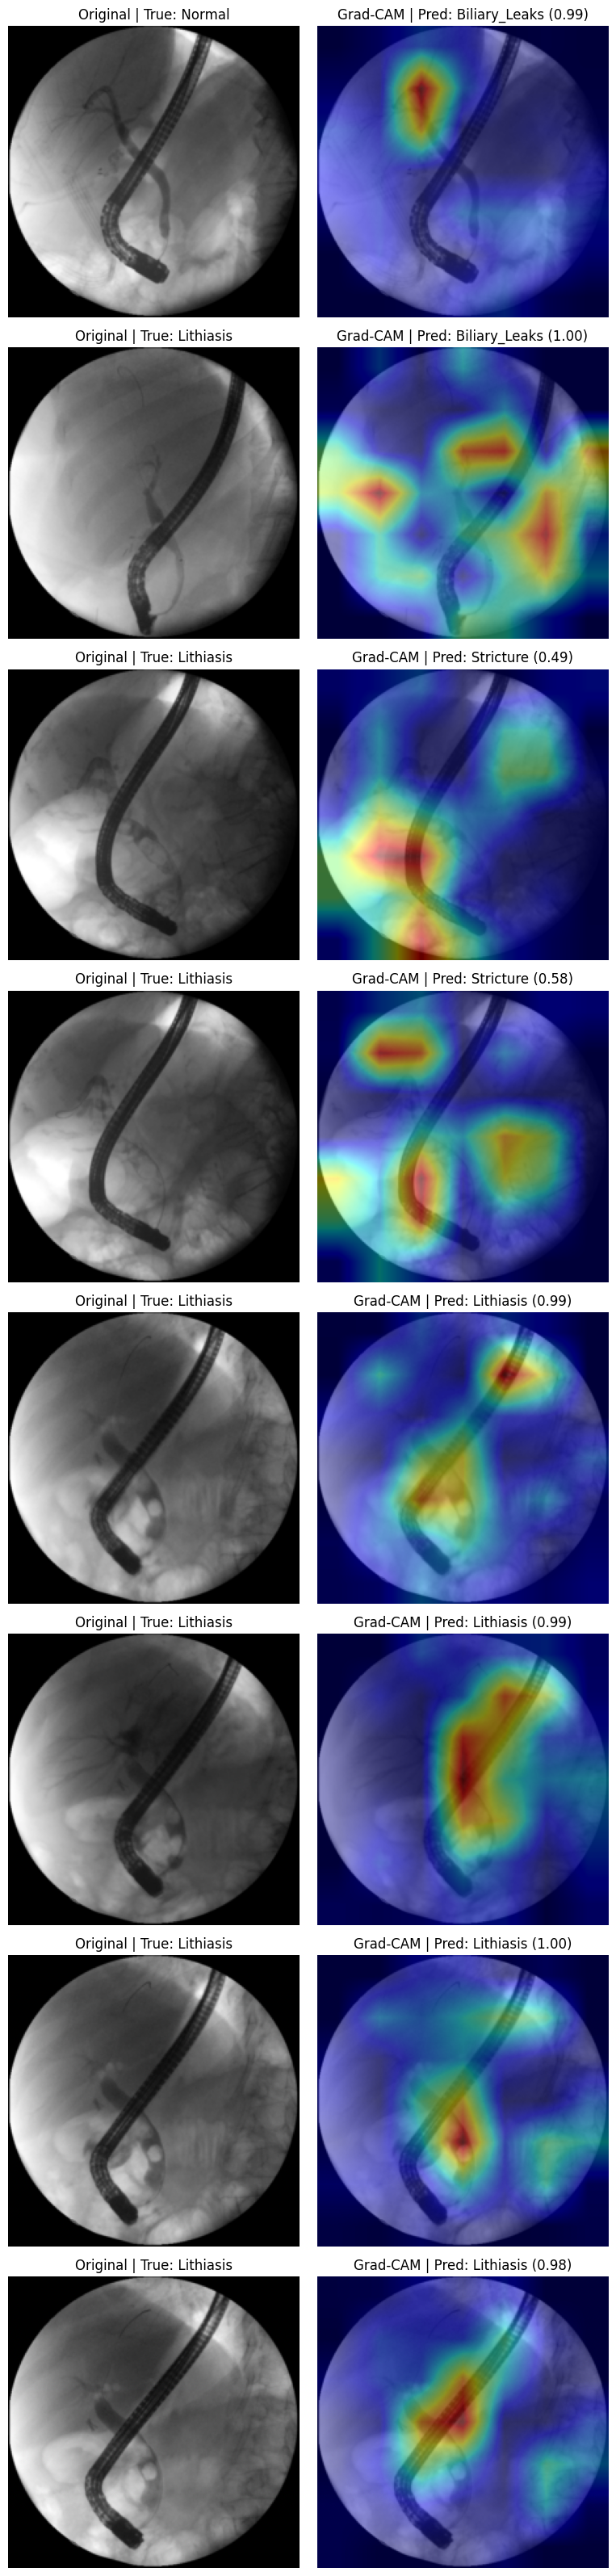

In [17]:
# =========================
# 16. Grad-CAM simples para MobileNetV3-Large
# =========================

RUN_GRADCAM = True

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.fwd_handle = target_layer.register_forward_hook(self.forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())
        score = output[:, class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


def denormalize_tensor(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    x = t.cpu() * std + mean
    return x.clamp(0, 1)


def show_gradcam_examples(model, dataset, df, n_examples=8):
    model.eval()
    target_layer = model.features[-1]
    cam_extractor = GradCAM(model, target_layer)

    # Misturar alguns certos e alguns erros, se existirem
    probs = probs_df.copy()
    candidate_indices = []
    if len(probs[~probs['correct']]) > 0:
        candidate_indices += probs[~probs['correct']].head(n_examples // 2).index.tolist()
    candidate_indices += probs[probs['correct']].head(n_examples).index.tolist()
    candidate_indices = candidate_indices[:n_examples]

    fig, axes = plt.subplots(len(candidate_indices), 2, figsize=(8, 4 * len(candidate_indices)))
    if len(candidate_indices) == 1:
        axes = np.expand_dims(axes, 0)

    for row, idx in enumerate(candidate_indices):
        img_tensor, true_label_idx = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        cam, pred_idx = cam_extractor(input_tensor)
        img_np = denormalize_tensor(img_tensor).permute(1, 2, 0).numpy()

        true_name = idx_to_class[int(true_label_idx)]
        pred_name = probs_df.iloc[idx]['pred_label']
        conf = probs_df.iloc[idx]['confidence']

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f'Original | True: {true_name}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(cam, cmap='jet', alpha=0.45)
        axes[row, 1].set_title(f'Grad-CAM | Pred: {pred_name} ({conf:.2f})')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'gradcam_examples.png', dpi=300, bbox_inches='tight')
    plt.show()
    cam_extractor.remove()

if RUN_GRADCAM:
    show_gradcam_examples(model, test_dataset, test_df, n_examples=8)
else:
    print('Grad-CAM desativado.')


In [18]:
# =========================
# 17. Resumo final para o relatório
# =========================

print('Resumo MobileNetV3-Large sem Focal Loss')
print('Split: train_manifest.csv / val_manifest.csv / test_manifest.csv')
print('Loss:', 'CrossEntropyLoss ponderada' if USE_CLASS_WEIGHTS else 'CrossEntropyLoss')
print('Weighted sampler:', USE_WEIGHTED_SAMPLER)
print('Melhor Val Macro F1:', round(best_val_f1, 4))
print('Test Macro F1:', round(test_metrics['macro_f1'], 4))
print('Test Balanced Accuracy:', round(test_metrics['balanced_accuracy'], 4))
print('Diferença para baseline 0.738:', round(test_metrics['macro_f1'] - BASELINE_MACRO_F1, 4))
print('Resultados guardados em:', RESULTS_DIR)
print('Modelo guardado em:', MODEL_PATH)


Resumo MobileNetV3-Large sem Focal Loss
Split: train_manifest.csv / val_manifest.csv / test_manifest.csv
Loss: CrossEntropyLoss ponderada
Weighted sampler: True
Melhor Val Macro F1: 0.523
Test Macro F1: 0.4675
Test Balanced Accuracy: 0.4718
Diferença para baseline 0.738: -0.2705
Resultados guardados em: /mounts/mecd-ap-g5/results/mobilenetv3_large_manifest_splits_no_focal
Modelo guardado em: /mounts/mecd-ap-g5/models/mobilenetv3_large_manifest_splits_no_focal/best_mobilenetv3_large_manifest_no_focal.pth
